# 5. Inclination estimation and Fourier-domain compression

## Estimating the inclination

The star's inclination is usually unknown, and getting it wrong warps the
recovered map. jittermap estimates it by refitting the surface at each
trial inclination and scoring the fit, the *profile objective* $J(\beta)$.
Scanning $J(\beta)$ shows how much each data type knows about the tilt.

The answer depends on what we are willing to assume about the surface.
This section walks through three assumptions, from weakest to strongest:
a completely free surface with no prior, a free surface with the GMRF
smoothness prior, and a surface known to consist of circular spots.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import jittermap as jm
from jittermap.plotting.render import build_projection_grid, render_surface_fast
from jittermap.plotting.panels import render_panel, normalize_map
GRID = build_projection_grid(n_grid=200)
X, Y, Z, THETA, PHI, MASK = GRID

def show_star(ax, coeffs, l_max, beta, title="", t=0.0):
    m = render_surface_fast(coeffs, l_max, beta, THETA, PHI, MASK, X, Y, Z, t=t)
    render_panel(ax, normalize_map(m), title, beta)
    ax.set_xticks([]); ax.set_yticks([])


light curve only: max MSE at wrong tilts (away from pole-on) = 2.2e-20


astrometry only: max MSE at wrong tilts (away from pole-on) = 1.1e-07


joint          : max MSE at wrong tilts (away from pole-on) = 7.0e-08


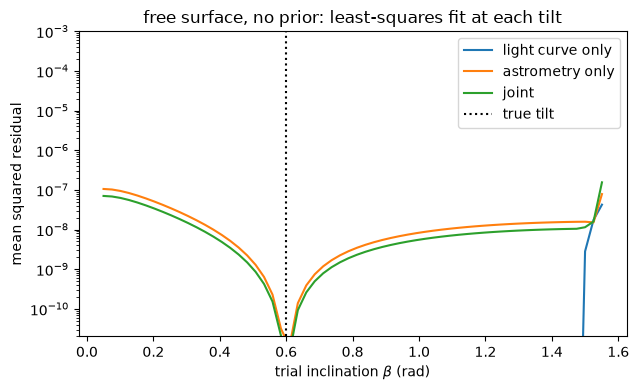

In [2]:
from jittermap.inference.inclination import profile_objective

L, N = 10, 100
INC_TRUE = 0.6
times = np.linspace(0, 2*np.pi, N, endpoint=False)
star = jm.multispot_surface([(30, 315, 18.0), (-15, 30, 13.0)], L,
                            texture_amplitude=0.002, texture_seed=3)
fm = jm.ForwardModel(times, l_max=L)
data = fm.observe(star, inclination=INC_TRUE, channels="xyp", stacked=False)

betas = np.linspace(0.05, np.pi/2 - 0.02, 60)

def scan(ch, lam):
    """Profile objective per data sample at each trial inclination."""
    y = np.concatenate([data[c] for c in ch])
    return np.array([profile_objective(b, y, ch, L, fm.kernels, fm._precomp,
                                       lam=lam) / y.size
                     for b in betas])

plt.figure(figsize=(6.5, 4))
for ch, label in [("p", "light curve only"), ("xy", "astrometry only"),
                  ("xyp", "joint")]:
    J = scan(ch, lam=0)
    plt.semilogy(betas, J, label=label)
    away = betas < 1.45
    print(f"{label:15s}: max MSE at wrong tilts (away from pole-on) = "
          f"{J[away].max():.1e}")
plt.axvline(INC_TRUE, color="k", ls=":", label="true tilt")
plt.ylim(2e-11, 1e-3)
plt.xlabel("trial inclination $\\beta$ (rad)")
plt.ylabel("mean squared residual")
plt.title("free surface, no prior: least-squares fit at each tilt")
plt.legend(); plt.tight_layout()

With no prior, the only thing that can expose a wrong tilt is the data
falling outside the column space of the design matrix at that tilt.
Photometry's design is too permissive for that to happen: the light
curve of any surface contains only $2L+1 = 21$ rotation harmonics (see
the Fourier section below) while the free surface has $(L+1)^2 = 121$
modes, so at every tilt away from pole-on some surface reproduces the
light curve exactly. Its residual sits at numerical zero across the
axis (off the bottom of the plot), and the inclination is completely
unidentifiable. The astrometric design is more rigid: at a wrong tilt
no free surface can reproduce both jitter channels at once, the
residual is real, and the minimum lands on the true tilt with almost
four decades of contrast.

Three caveats keep this honest. The scan is noiseless. Near pole-on the
picture degrades: the photometric design degenerates enough that even
the light curve finally leaves a residual (the spike at the right
edge), while astrometry picks up a shallow spurious local minimum. And
an objective that is exactly zero over most of the axis is useless as
an estimator, which is precisely the situation a prior is for.

## What the prior does

The GMRF prior scores the *plausibility* of the surface each tilt needs.
Reproducing the data at the wrong tilt requires a rougher, more contorted
surface, and the penalty term exposes that even where the residual alone
is blind:

light curve only lambda = 0.0002: minimum at beta = 0.432


light curve only lambda =   0.02: minimum at beta = 0.457


astrometry only lambda = 0.0002: minimum at beta = 0.482


astrometry only lambda =   0.02: minimum at beta = 0.381


joint           lambda = 0.0002: minimum at beta = 0.584


joint           lambda =   0.02: minimum at beta = 0.584


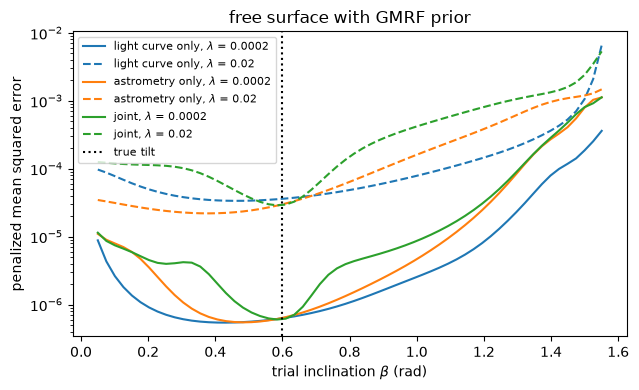

In [3]:
plt.figure(figsize=(6.5, 4))
colors = {"p": "C0", "xy": "C1", "xyp": "C2"}
for ch, label in [("p", "light curve only"), ("xy", "astrometry only"),
                  ("xyp", "joint")]:
    for lam, ls in [(2e-4, "-"), (2e-2, "--")]:
        J = scan(ch, lam)
        plt.semilogy(betas, J, ls, color=colors[ch],
                     label=f"{label}, $\\lambda$ = {lam:g}")
        print(f"{label:15s} lambda = {lam:6g}: minimum at "
              f"beta = {betas[np.argmin(J)]:.3f}")
plt.axvline(INC_TRUE, color="k", ls=":", label="true tilt")
plt.xlabel("trial inclination $\\beta$ (rad)")
plt.ylabel("penalized mean squared error")
plt.title("free surface with GMRF prior")
plt.legend(fontsize=8); plt.tight_layout()

The prior changes each channel differently:

- **Light curve.** From literally zero information to a curved objective.
  But the minimum lands away from the truth and the basin stays broad:
  the photometric inclination ambiguity is genuine, and a smoothness
  prior can only reveal it, not remove it.
- **Astrometry.** The prior removes the spurious near-pole-on local
  minimum, at the price of a small bias on noiseless data: the penalty
  trades data fidelity for smoothness, and it pays that trade slightly
  differently at different tilts.
- **Joint.** A single stable minimum near the truth at both prior
  strengths. This combination, free surface plus GMRF prior plus both
  data types, is what `reconstruct` uses:

In [4]:
for ch, label in [("p", "light curve"), ("xy", "astrometry"), ("xyp", "joint")]:
    res = jm.reconstruct({c: data[c] for c in ch}, times, L, channels=ch,
                         lam=2e-4, model=fm)
    print(f"{label:11s}: estimated tilt {res.inclination:.3f} rad "
          f"(true {INC_TRUE})")

light curve: estimated tilt 0.426 rad (true 0.6)
astrometry : estimated tilt 0.484 rad (true 0.6)


joint      : estimated tilt 0.588 rad (true 0.6)


## A spots-only surface model

The strongest assumption is parametric: the surface is known to be a
small number of circular spots, and we fit only their latitudes,
longitudes and radii. This is the regime where the familiar claim
"astrometry pins down the inclination, photometry does not" is cleanest.
At each trial tilt we refit the six spot parameters by direct
optimization, with a few restarts to guard against local minima (this
cell takes about half a minute):

light curve only: minimum at beta = 0.518


astrometry only: minimum at beta = 0.601


joint          : minimum at beta = 0.601


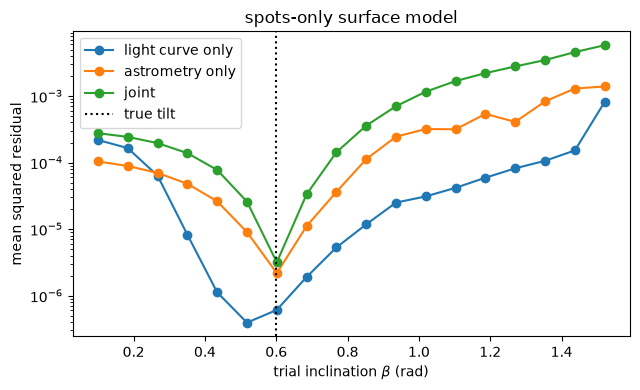

In [5]:
from scipy.optimize import minimize
from jittermap.forward.design import design_matrix_vandermonde

p_true = np.array([30, 315, 18.0, -15, 30, 13.0])

def spot_mse(params, D, y):
    s = jm.multispot_surface([(params[0], params[1], params[2]),
                              (params[3], params[4], params[5])], L)
    r = y - (D @ s).real
    return float(np.mean(r**2))

def profile_spot(beta, ch):
    D = np.vstack([design_matrix_vandermonde(L, beta, fm.kernels[c],
                                             *fm._precomp) for c in ch])
    y = np.concatenate([data[c] for c in ch])
    inits = [p_true,
             p_true * np.array([-1, 1, 1, -1, 1, 1]),
             p_true + np.array([15, 20, -4, -10, -20, 4])]
    return min(minimize(spot_mse, p0, args=(D, y), method="Nelder-Mead",
                        options={"maxiter": 600, "fatol": 1e-12,
                                 "xatol": 1e-4}).fun
               for p0 in inits)

betas_s = np.linspace(0.1, np.pi/2 - 0.05, 18)
plt.figure(figsize=(6.5, 4))
for ch, label in [("p", "light curve only"), ("xy", "astrometry only"),
                  ("xyp", "joint")]:
    Js = np.array([profile_spot(b, ch) for b in betas_s])
    plt.semilogy(betas_s, Js, "o-", label=label)
    print(f"{label:15s}: minimum at beta = {betas_s[np.argmin(Js)]:.3f}")
plt.axvline(INC_TRUE, color="k", ls=":", label="true tilt")
plt.xlabel("trial inclination $\\beta$ (rad)")
plt.ylabel("mean squared residual")
plt.title("spots-only surface model")
plt.legend(); plt.tight_layout()

Now the claim is actually on the screen. The astrometric objective has a
single basin whose minimum lands exactly on the true tilt, with orders
of magnitude of contrast. The photometric objective also has a basin
now, but its minimum is displaced to $\beta \approx 0.52$ rad and the
truth sits on its shoulder at nearly the same depth: even noiseless
photometry under a hard spots-only model cannot decide between tilts
across roughly 0.45 to 0.65 rad, and its best guess is not the truth.
The joint fit inherits the astrometric answer and adds contrast.

Taken together, the three regimes give the honest version of the
argument. With a completely unconstrained surface, identifiability is
set by the rigidity of each channel's design matrix, and only astrometry
has any. The GMRF prior makes the estimation problem well posed but
cannot cure the photometric ambiguity. And the more we are entitled to
assume about the surface, the more decisively astrometry converts that
assumption into an inclination measurement.

## The signal is a frequency comb

One practical bonus of the model: for uniform sampling over a rotation,
the signals contain only the harmonics $m\omega$ of the rotation rate,
$m = -L..L$. So $N$ time samples compress **losslessly** into just $2L+1$
Fourier coefficients — handy for storing and fitting long campaigns:

compressed data still fits the model exactly: True
100 time samples -> 21 numbers, nothing lost


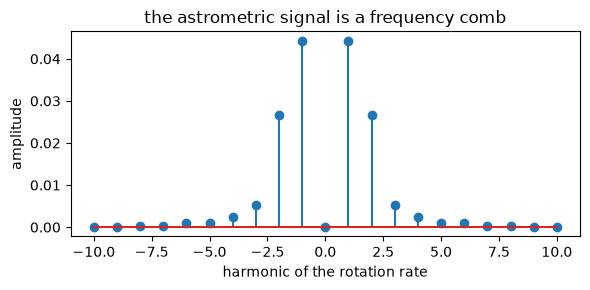

In [6]:
from jittermap.forward.fourier import compress, fourier_design_matrix
from jittermap.forward.kernels import compute_A_lm

A_x, _ = compute_A_lm(L)
y_x = fm.observe(star, INC_TRUE, channels="x")
f = compress(y_x, L)
F = fourier_design_matrix(L, INC_TRUE, A_x)
print("compressed data still fits the model exactly:",
      np.allclose(f, F @ star, atol=1e-12))
print(f"{N} time samples -> {2*L+1} numbers, nothing lost")

m_vals = np.arange(-L, L+1)
plt.figure(figsize=(6, 3))
plt.stem(m_vals, np.abs(f))
plt.xlabel("harmonic of the rotation rate")
plt.ylabel("amplitude")
plt.title("the astrometric signal is a frequency comb")
plt.tight_layout()